# <center>CHAPTER 1</center>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")

All libraries loaded successfully!


Monte Carlo Valuation of European Call Option
Black-Scholes-Merton model

In [10]:
import math 
import numpy as np

#parameter values

S0 = 100 #initial stock price
K = 105 #strike price
T=1 #time to maturity in years
r = 0.05 #risk free rate
sigma = 0.2 #volatility

I=10000 #number of simulations
Z=np.random.standard_normal(I) #generate standard normal random variables
ST= S0*np.exp((r-0.5*sigma**2)*T + sigma*np.sqrt(T)*Z) #simulate stock price at maturity
payoff = np.maximum(ST-K,0) #calculate payoff for call option
C0= math.exp(-r*T)*np.mean(payoff) #discount payoff back to present value

print(f"The estimated price of the European call option is: {C0:.2f}")


The estimated price of the European call option is: 8.16


Consider a finance student interested in S&P 500 index values.
They want to analyze historical index levels for a few years to see how the volatility of the index has fluctuated over time and hope to find evidence that volatility, contrary to typical model assumptions, fluctuates over time and is far from being constant. 

STEPS:
Retreive index level data from the web
Calculate teh annualized rolling standard deviation of the log returns (volatility)
Plot the index level data and the volatility results

PAGE 19 (39 in pdf)

In [11]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


--------------------------------------------------
               .SPX      rets  vola
Date                               
2010-01-04  1132.99       NaN   NaN
2010-01-05  1136.52  0.003111   NaN
2010-01-06  1137.14  0.000545   NaN
2010-01-07  1141.69  0.003993   NaN
2010-01-08  1144.98  0.002878   NaN
--------------------------------------------------


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

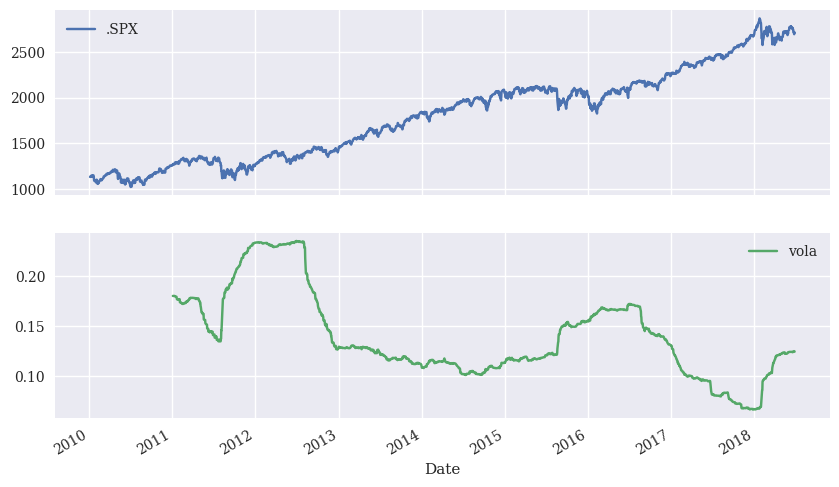

In [12]:
import numpy as np
import pandas as pd
from pylab import plt, mpl


%matplotlib inline
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'


data= pd.read_csv('https://raw.githubusercontent.com/yhilpisch/py4fi2nd/master/source/tr_eikon_eod_data.csv',
                    index_col=0, parse_dates=True)

#print(data)
#print('-' * 50)
#print(data['.SPX'])
#print('-' * 50)
data=pd.DataFrame(data['.SPX'])
data.dropna(inplace=True)
#data.info()
print('-' * 50)

#print(data.head())
#print('-' * 50)

data['rets']=np.log(data / data.shift(1))
#print(data.head())
#print('-' * 50)
data['vola']=data['rets'].rolling(252).std() * np.sqrt(252)
print(data.head())
print('-' * 50)
data[['.SPX','vola']].plot(subplots=True, figsize=(10,6))



PAGE 22 (42 in pdf)

A quite common task in financial analytics is to evaluate complex mathematical expressions on large arrays of numbers. 

In [13]:
import math
loops=25000
a=range(loops)
def f(x):
    return 3*math.log(x)+math.cos**2

import numpy as np
a=np.arange(loops)



Numpy is much faster in doing this

=========================================================

Brief example to demonstrate how easy it has become to retreive data on a large scale

The following example retreives tick data for Apple stock for one hour during a regular trading day. 

In [14]:
%pip install eikon

Note: you may need to restart the kernel to use updated packages.


In [15]:
import eikon as ek

data=ek.get_timeseries('AAPL.O',fields='*',
                       start_date='2018-10-18 16:00:00',
                       end_date='2018-10-18 17:00:00',
                       interval='tick')

data.info()


HTTP request failed: 'NoneType' object has no attribute 'http_request'


AttributeError: 'NoneType' object has no attribute 'info'

Doesnt work since eikon requires a subscription to get the appkey

=========================================================

One of the most widely used Python packages for ML is scikit-learn

The code that follows shows how, in a highly simplified manner, classification algorithms from ML can be used to predict the direction of future market price movements and to base an algorithmic trading strategy on those predictions

In [ ]:
%pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------

               AAPL.O   Returns     lag_1     lag_2     lag_3     lag_4  \
Date                                                                      
2010-01-13  30.092827  0.014007 -0.011440 -0.008861  0.006626 -0.001850   
2010-01-14  29.918542 -0.005808  0.014007 -0.011440 -0.008861  0.006626   
2010-01-15  29.418542 -0.016853 -0.005808  0.014007 -0.011440 -0.008861   
2010-01-20  30.246398 -0.015536 -0.016853 -0.005808  0.014007 -0.011440   
2010-01-21  29.724542 -0.017404 -0.015536 -0.016853 -0.005808  0.014007   

               lag_5     lag_6  
Date                            
2010-01-13 -0.016034  0.001727  
2010-01-14 -0.001850 -0.016034  
2010-01-15  0.006626 -0.001850  
2010-01-20 -0.008861  0.006626  
2010-01-21 -0.011440 -0.008861  


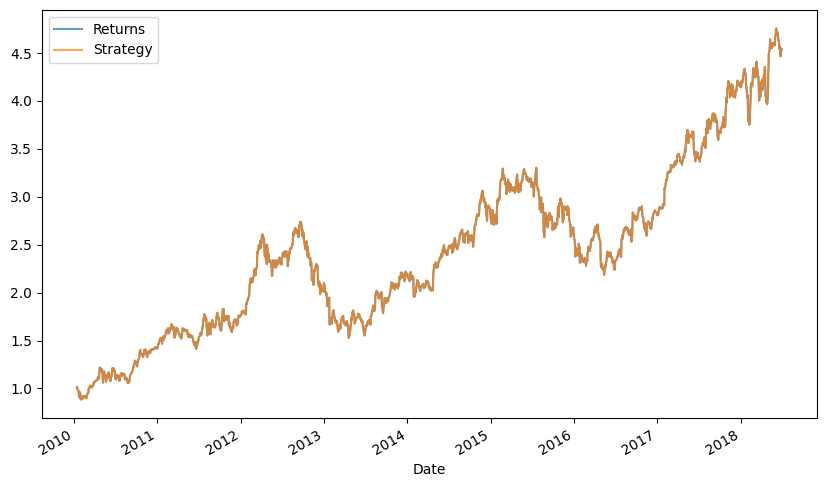

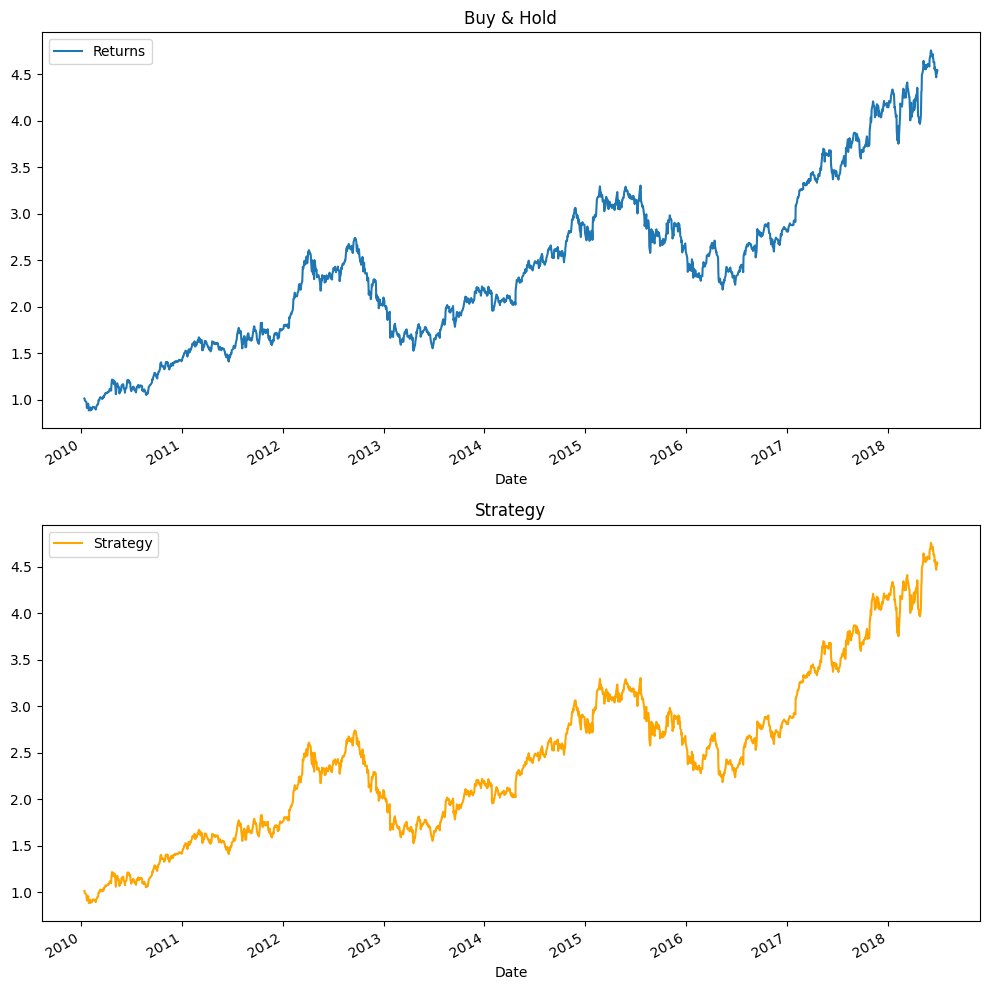

In [ ]:
import numpy as np
import pandas as pd

data=pd.read_csv('https://raw.githubusercontent.com/yhilpisch/py4fi2nd/master/source/tr_eikon_eod_data.csv', 
                 index_col=0, parse_dates=True)

data=pd.DataFrame(data['AAPL.O'])
data['Returns']=np.log(data / data.shift())
data.dropna(inplace=True)

lags=6

cols=[]
for lag in range(1,lags+1):
    col=f'lag_{lag}'
    data[col]=data['Returns'].shift(lag)
    cols.append(col)

data.dropna(inplace=True)
print(data.head())

from sklearn.svm import SVC

model = SVC(gamma='auto')

model.fit(data[cols], np.sign(data['Returns']))

data['Prediction']=model.predict(data[cols])

data['Strategy']=data['Prediction']*data['Returns']

data[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(figsize=(10,6), alpha=0.7)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

data[['Returns']].cumsum().apply(np.exp).plot(ax=ax1, title='Buy & Hold')
data[['Strategy']].cumsum().apply(np.exp).plot(ax=ax2, title='Strategy', color='orange')

plt.tight_layout()
plt.show()

something is wrong here